# 2. óra — Gépi tanulás: élő demók

Ezt a notebookot óra közben vetítjük ki, a `lesson-plan.md`-ben jelzett pontokon.
Ez a notebook **generálja** a `slides.html`-ben használt gif-eket is (az
`assets/` mappába) — ha újrafuttatod, felülírja őket.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(7)

# a deck.css sötét "kártyaasztal" paletta — hogy a diákra vetített ábrák ne
# fehér téglalapként üssenek ki a sötét diákból
INK, INK_DIM, BG, BG_RAISED, ACCENT, TENSION = (
    "#e9e4d2", "#b9c2b3", "#0d2a20", "#123626", "#d1a13a", "#c1543a",
)
plt.rcParams.update({
    "figure.figsize": (6, 4.5),
    "figure.facecolor": BG_RAISED,
    "savefig.facecolor": BG_RAISED,
    "axes.facecolor": BG_RAISED,
    "axes.edgecolor": INK_DIM,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_DIM,
    "ytick.color": INK_DIM,
    "grid.color": "#2a4536",
    "legend.facecolor": BG,
    "legend.edgecolor": INK_DIM,
    "legend.labelcolor": INK,
})

ASSETS = Path("assets")
ASSETS.mkdir(exist_ok=True)

## 1. Bias-variance tradeoff — polinom illesztés

Zajos, enyhén hullámzó adat. Növekvő fokszámú polinomokat illesztünk rá.

In [2]:
x_true = np.linspace(0, 10, 400)
y_true = 1 + 0.4 * x_true * np.sin(x_true)

n_points = 30
x_sample = np.sort(rng.uniform(0, 10, n_points))
y_sample = 1 + 0.4 * x_sample * np.sin(x_sample) + rng.normal(0, 1.2, n_points)

# nyers x-eket (0-10) magas fokszámnál numerikusan rosszul kondicionált a
# polinom-illesztés (lebegőpontos műveletek "véletlenszerűen" stabilabbá/
# instabilabbá válnak fokszámonként) — ezért [-1, 1] tartományba skálázunk,
# hogy a görbe valódi, tiszta bias-variance történetet mutasson
def scale_x(x):
    return (x - 5) / 5

degrees = list(range(1, 16))

fig, ax = plt.subplots()

y_lo, y_hi = y_sample.min() - 6, y_sample.max() + 6

def draw_degree(degree):
    ax.clear()
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(scale_x(x_sample).reshape(-1, 1), y_sample)
    y_pred = model.predict(scale_x(x_true).reshape(-1, 1))
    # magas fokszámnál a görbe milliós nagyságrendbe szállhat el — a plafonhoz/
    # padlóhoz tapadva ábrázoljuk, hogy lássuk: "kirepül a képből", ne törje szét a tengelyt
    y_pred_clipped = np.clip(y_pred, y_lo, y_hi)

    ax.scatter(x_sample, y_sample, color="#7fb3d5", zorder=3, label="adat")
    ax.plot(x_true, y_true, color=INK_DIM, linestyle="--", linewidth=1, label="valódi függvény")
    ax.plot(x_true, y_pred_clipped, color=TENSION, linewidth=2, label=f"fokszám = {degree}")
    ax.set_ylim(y_lo, y_hi)
    ax.legend(loc="upper left")
    ax.set_title("Polinom illesztés — növekvő fokszám")

anim = animation.FuncAnimation(fig, draw_degree, frames=degrees, interval=500)
anim.save(ASSETS / "polynomial_overfit.gif", writer=animation.PillowWriter(fps=2))
plt.close(fig)
print("mentve:", ASSETS / "polynomial_overfit.gif")

mentve: assets/polynomial_overfit.gif


### Train/test hiba a fokszám függvényében

A klasszikus U-alakú görbe: a tanuló hiba monoton csökken, a teszt hiba egy
pont után **nő** — ez az overfitting empirikus jele.

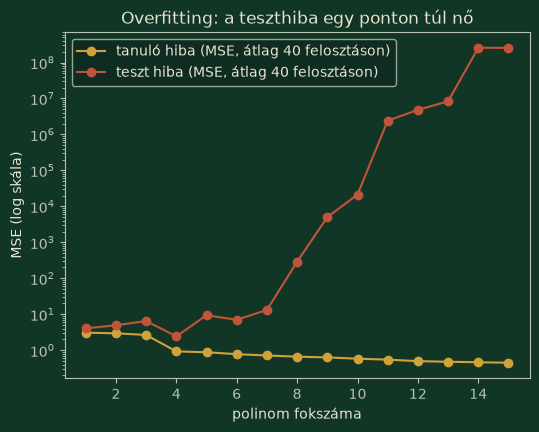

In [3]:
# egyetlen véletlen felosztás túl zajos lenne 22 ponton (egy-egy "szerencsés"
# felosztás önmagában eltorzítaná a görbét) — ezért sok véletlen felosztás
# átlagát nézzük fokszámonként, mint egy egyszerű ismételt hold-out validáció
from sklearn.model_selection import ShuffleSplit

splitter = ShuffleSplit(n_splits=40, test_size=0.35, random_state=7)

train_errors, test_errors = [], []
for degree in degrees:
    train_mse, test_mse = [], []
    for train_idx, test_idx in splitter.split(x_sample):
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        x_scaled = scale_x(x_sample)
        model.fit(x_scaled[train_idx].reshape(-1, 1), y_sample[train_idx])
        train_mse.append(np.mean((model.predict(x_scaled[train_idx].reshape(-1, 1)) - y_sample[train_idx]) ** 2))
        test_mse.append(np.mean((model.predict(x_scaled[test_idx].reshape(-1, 1)) - y_sample[test_idx]) ** 2))
    train_errors.append(np.mean(train_mse))
    test_errors.append(np.mean(test_mse))

plt.figure()
plt.plot(degrees, train_errors, marker="o", color=ACCENT, label="tanuló hiba (MSE, átlag 40 felosztáson)")
plt.plot(degrees, test_errors, marker="o", color=TENSION, label="teszt hiba (MSE, átlag 40 felosztáson)")
plt.yscale("log")
plt.xlabel("polinom fokszáma")
plt.ylabel("MSE (log skála)")
plt.title("Overfitting: a teszthiba egy ponton túl nő")
plt.legend()
plt.show()

## 2. Titanic adatsor

A klasszikus (Kaggle-eredetű, itt a szabadon elérhető seaborn-tükörből
letöltött) Titanic utaslista. Egyszerű tisztítás: hiányzó életkor mediánnal,
kategorikus oszlopok kódolása, a sok hiányzó `deck` eldobása.

In [4]:
titanic = pd.read_csv("data/titanic.csv")

titanic["age"] = titanic["age"].fillna(titanic["age"].median())
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])

features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = pd.get_dummies(titanic[features], columns=["sex", "embarked"], drop_first=True)
y = titanic["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

print(X.shape, "| túlélési arány:", round(y.mean(), 2))
X.head()

(891, 8) | túlélési arány: 0.38


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## 3. Gradient descent — learning rate

Egy hullámzó (nem konvex) 1D felületen nézzük meg, mit csinál 3 különböző
learning rate.

In [5]:
def loss(w):
    return 0.3 * w**2 + 3 * np.sin(w)

def grad(w):
    return 0.6 * w + 3 * np.cos(w)

w_grid = np.linspace(-8, 8, 400)

learning_rates = {"túl kicsi (0.02)": 0.02, "jó (0.25)": 0.25, "túl nagy (1.05)": 1.05}
n_steps = 25
start = -7.0

paths = {}
for label, lr in learning_rates.items():
    w = start
    path = [w]
    for _ in range(n_steps):
        w = w - lr * grad(w)
        w = np.clip(w, -8, 8)
        path.append(w)
    paths[label] = path

fig, ax = plt.subplots()
colors = {"túl kicsi (0.02)": "#7fb3d5", "jó (0.25)": ACCENT, "túl nagy (1.05)": TENSION}

def draw_step(step):
    ax.clear()
    ax.plot(w_grid, loss(w_grid), color=INK_DIM, linewidth=1, alpha=0.5)
    for label, path in paths.items():
        i = min(step, len(path) - 1)
        ax.plot(path[: i + 1], [loss(v) for v in path[: i + 1]], "o-", color=colors[label], label=label, markersize=4)
    ax.set_title(f"Gradient descent — {step}. lépés")
    ax.set_xlabel("paraméter (w)")
    ax.set_ylabel("hiba")
    ax.legend(loc="upper center")
    ax.set_ylim(-5, 25)

anim = animation.FuncAnimation(fig, draw_step, frames=n_steps + 1, interval=300)
anim.save(ASSETS / "gradient_descent_lr.gif", writer=animation.PillowWriter(fps=4))
plt.close(fig)
print("mentve:", ASSETS / "gradient_descent_lr.gif")

mentve: assets/gradient_descent_lr.gif


## 4. Közös segédfüggvény a döntési-határ animációkhoz

Egyetlen 2D toy adathalmazon (`make_moons`) mutatjuk be a fa, a random forest,
a gradient boosting és a neurális háló tanulását — így egymással is
összevethető, ahogy különbözőképp birkóznak meg ugyanazzal a problémával.

In [6]:
X_toy, y_toy = make_moons(n_samples=300, noise=0.25, random_state=7)

xx, yy = np.meshgrid(
    np.linspace(X_toy[:, 0].min() - 0.5, X_toy[:, 0].max() + 0.5, 150),
    np.linspace(X_toy[:, 1].min() - 0.5, X_toy[:, 1].max() + 0.5, 150),
)
grid = np.c_[xx.ravel(), yy.ravel()]


def animate_boundary(frame_predictions, frame_labels, filename, title):
    fig, ax = plt.subplots()

    def draw(i):
        ax.clear()
        Z = frame_predictions[i].reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.35, levels=[-0.5, 0.5, 1.5], colors=["#d1a13a", "#0d2a20"])
        ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, cmap="coolwarm", edgecolor="white", linewidth=0.4, s=25)
        ax.set_title(f"{title}\n{frame_labels[i]}")
        ax.set_xticks([])
        ax.set_yticks([])

    anim = animation.FuncAnimation(fig, draw, frames=len(frame_predictions), interval=500)
    anim.save(ASSETS / filename, writer=animation.PillowWriter(fps=2))
    plt.close(fig)
    print("mentve:", ASSETS / filename)

## 5. Egyszerű döntési fa — mélység

In [7]:
depths = [1, 2, 3, 4, 5, 6, 8, 12]
preds, labels = [], []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=7).fit(X_toy, y_toy)
    preds.append(tree.predict(grid))
    labels.append(f"mélység = {d}")

animate_boundary(preds, labels, "tree_depth.gif", "Döntési fa — növekvő mélység")

mentve: assets/tree_depth.gif


## 6. Random Forest — bagging csökkenti a varianciát

In [8]:
n_trees_list = [1, 2, 5, 10, 25, 50, 100, 200]
preds, labels = [], []
for n in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n, max_depth=6, random_state=7).fit(X_toy, y_toy)
    preds.append(rf.predict(grid))
    labels.append(f"{n} fa")

animate_boundary(preds, labels, "random_forest_ensemble.gif", "Random Forest — egyre több fa")

mentve: assets/random_forest_ensemble.gif


## 7. Gradient Boosting — szekvenciális tanulás

In [9]:
gbm = GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.3, random_state=7)
gbm.fit(X_toy, y_toy)

rounds = [1, 2, 5, 10, 25, 50, 100, 200]
preds, labels = [], []
staged = list(gbm.staged_predict(grid))
for r in rounds:
    preds.append(staged[r - 1])
    labels.append(f"{r}. kör")

animate_boundary(preds, labels, "gradient_boosting_rounds.gif", "Gradient Boosting — egyre több kör")

mentve: assets/gradient_boosting_rounds.gif


## 8. Neurális háló tanulása

`warm_start=True` + ismételt `fit()` hívás egy-egy extra epoch erejéig, hogy
lássuk a döntési határ alakulását tanítás közben.

In [10]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    max_iter=1,
    warm_start=True,
    random_state=7,
    learning_rate_init=0.05,
)

checkpoints = [1, 2, 5, 10, 25, 50, 100, 200]
preds, labels = [], []
for epoch in range(1, max(checkpoints) + 1):
    mlp.fit(X_toy, y_toy)
    if epoch in checkpoints:
        preds.append(mlp.predict(grid))
        labels.append(f"{epoch}. epoch")

animate_boundary(preds, labels, "neural_network_training.gif", "Neurális háló — tanítás közben")

/home/karpatika92/nasz_data_science_course/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/karpatika92/nasz_data_science_course/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/karpatika92/nasz_data_science_course/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/karpatika92/nasz_data_science_course/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached 

mentve: assets/neural_network_training.gif


## 9. Modellösszehasonlítás a Titanicon

Ugyanazon a train/test felosztáson: logisztikus regresszió (baseline), SVM,
egyszerű fa, Random Forest, Gradient Boosting, neurális háló.

Gradient Boosting         0.843
SVM                       0.825
Random Forest             0.821
Döntési fa                0.821
Neurális háló             0.798
Logisztikus regresszió    0.771
dtype: float64


/home/karpatika92/nasz_data_science_course/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


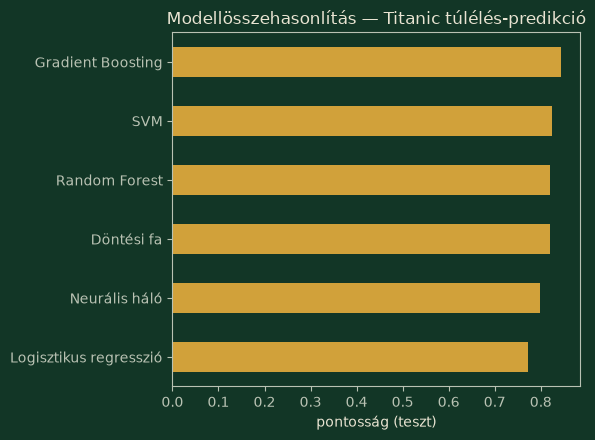

In [11]:
models = {
    "Logisztikus regresszió": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="rbf"),
    "Döntési fa": DecisionTreeClassifier(max_depth=4, random_state=7),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=7),
    "Gradient Boosting": GradientBoostingClassifier(random_state=7),
    "Neurális háló": MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=500, random_state=7),
}

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    results[name] = accuracy_score(y_test, model.predict(X_test_scaled))

results_df = pd.Series(results).sort_values(ascending=False)
print(results_df.round(3))

plt.figure()
results_df.plot(kind="barh", color="#d1a13a")
plt.xlabel("pontosság (teszt)")
plt.title("Modellösszehasonlítás — Titanic túlélés-predikció")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()